# Hospital Readmission Prediction

Every year, US hospitals spend ~$26 billion on patients readmitted within 30 days of discharge. Many of these readmissions are preventable — if you could flag high-risk patients at discharge, you could intervene before they come back.

Your goal: build a model that predicts whether a diabetic patient will be readmitted within 30 days, based on their hospital visit data.

## What makes this different from Titanic
- **100,000+ rows** — real scale, not a toy dataset
- **~50 messy columns** — you'll have to make decisions about what to keep
- **Imbalanced classes** — only ~11% of patients are readmitted early, which breaks naive accuracy
- **Medical features** — medications, diagnoses, lab results, prior visits

## What you'll learn
- How to handle severely imbalanced datasets
- More aggressive feature engineering on messy real data
- Why accuracy is a misleading metric for imbalanced problems
- How `class_weight` fixes the imbalance problem

In [5]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import urllib.request
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

print('Libraries loaded!')

Libraries loaded!


## Step 1: Load the Data

The dataset is the **Diabetes 130-US Hospitals** dataset from UCI — 10 years of diabetic patient records across 130 US hospitals (1999–2008).

Each row is one hospital visit. The target column `readmitted` has three values:
- `<30` — readmitted within 30 days (the bad outcome we want to predict)
- `>30` — readmitted after 30 days
- `NO` — not readmitted

We'll turn this into a binary problem: did the patient come back within 30 days?

In [9]:
import ssl

data_dir = Path.home() / 'LocalAI' / 'data' / 'readmission'
data_dir.mkdir(parents=True, exist_ok=True)

csv_path = data_dir / 'dataset_diabetes' / 'diabetic_data.csv'

if not csv_path.exists():
    print('Downloading dataset (~4MB)...')
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip'
    zip_path = data_dir / 'dataset_diabetes.zip'
    # UCI's SSL cert is expired — bypass verification for this known dataset
    ssl._create_default_https_context = ssl._create_unverified_context
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(data_dir)
    print('Downloaded!')
else:
    print('Data already downloaded.')

df = pd.read_csv(csv_path)
print(f'Shape: {df.shape}')
df.head()

Data already downloaded.
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Step 2: Explore the Data

Before touching anything, understand what you have. Real hospital data is messy — missing values are encoded as `?`, some columns are nearly empty, and the target is heavily imbalanced.

In [7]:
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()

# This dataset uses '?' instead of NaN for missing values
print('Missing values (encoded as ?):')  
for col in df.columns:
    n_missing = (df[col] == '?').sum()
    if n_missing > 0:
        pct = n_missing / len(df)
        print(f'  {col:<30} {n_missing:>6,}  ({pct:.1%})')

Rows: 101,766
Columns: 50

Missing values (encoded as ?):
  race                            2,273  (2.2%)
  weight                         98,569  (96.9%)
  payer_code                     40,256  (39.6%)
  medical_specialty              49,949  (49.1%)
  diag_1                             21  (0.0%)
  diag_2                            358  (0.4%)
  diag_3                          1,423  (1.4%)


Readmission breakdown:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Early readmission rate: 11.2%


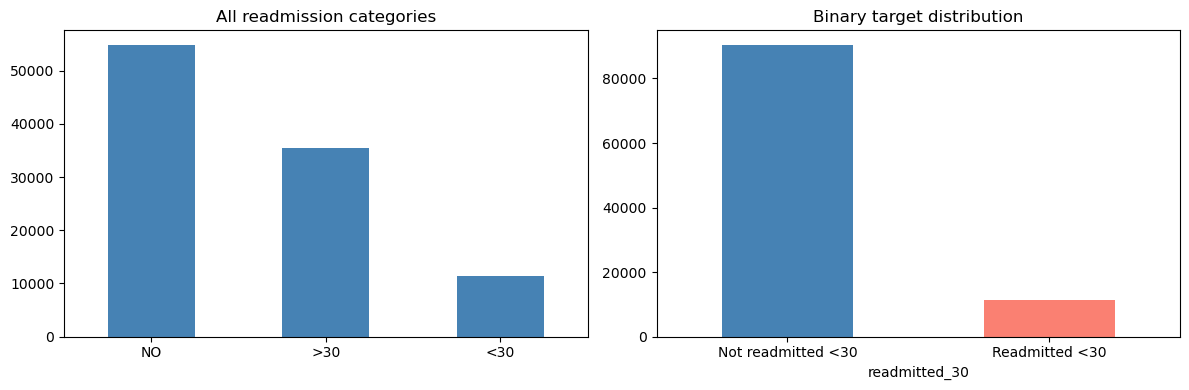


This is imbalanced — ~11 negatives for every positive.
A model that always predicts "not readmitted" would be 89% accurate but catch zero readmissions.


In [10]:
# Create the binary target: 1 = readmitted within 30 days, 0 = everything else
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print('Readmission breakdown:')
print(df['readmitted'].value_counts())
print()
print(f'Early readmission rate: {df["readmitted_30"].mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('All readmission categories')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df['readmitted_30'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_xticklabels(['Not readmitted <30', 'Readmitted <30'], rotation=0)
axes[1].set_title('Binary target distribution')

plt.tight_layout()
plt.show()

print()
print('This is imbalanced — ~11 negatives for every positive.')
print('A model that always predicts "not readmitted" would be 89% accurate but catch zero readmissions.')

## Step 3: Clean the Data

This is the most important step. You need to decide:
- Which columns to **drop** (too many missing values, not clinically useful)
- How to handle `?` values
- How to convert non-numeric columns to numbers

The diagnosis columns (`diag_1`, `diag_2`, `diag_3`) are ICD-9 codes — complex medical codes that could be valuable but require significant domain knowledge to use well. We'll skip them for now.

In [ ]:
data = df.copy()

# Drop columns that are too messy or not useful for prediction
drop_cols = [
    'encounter_id', 'patient_nbr',       # row IDs, not features
    'weight',                              # 97% missing
    'payer_code',                          # insurance type, not predictive
    'medical_specialty',                   # 50% missing
    'diag_1', 'diag_2', 'diag_3',         # ICD codes — complex enough for their own project
    'readmitted',                           # original target (replaced by readmitted_30)
]
data = data.drop(columns=drop_cols)

# Replace '?' with NaN and drop rows with any remaining missing values
data = data.replace('?', np.nan).dropna()
print(f'Rows after cleaning: {len(data):,}  (dropped {len(df) - len(data):,} rows with missing values)')

# Age comes as brackets like '[50-60)' — convert to midpoint numbers
age_map = {
    '[0-10)': 5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
data['age'] = data['age'].map(age_map)

# Gender: drop the rare 'Unknown/Invalid' entries, then encode
data = data[data['gender'] != 'Unknown/Invalid']
data['gender'] = data['gender'].map({'Male': 0, 'Female': 1})

# Race: label encode
data['race'] = LabelEncoder().fit_transform(data['race'].astype(str))

print('Cleaned!')
data.head()

## Step 4: Feature Engineering

The medication columns (`metformin`, `insulin`, etc.) have values like `No`, `Steady`, `Up`, `Down` — whether the patient was on that drug and whether the dose changed.

We'll simplify: `No` = 0 (not prescribed), anything else = 1 (prescribed).

We'll also create a new feature: **total number of medications prescribed**, which might be a proxy for how sick the patient is.

In [ ]:
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# No = 0, any other value (Steady/Up/Down) = 1
for col in med_cols:
    if col in data.columns:
        data[col] = (data[col] != 'No').astype(int)

# Binary columns
data['change'] = (data['change'] == 'Ch').astype(int)         # medication regimen changed
data['diabetesMed'] = (data['diabetesMed'] == 'Yes').astype(int)

# New feature: total medications prescribed — proxy for patient complexity
data['num_meds_prescribed'] = data[[c for c in med_cols if c in data.columns]].sum(axis=1)

print('Feature engineering done!')
print(f'Shape: {data.shape}')
print(f'\nAvg medications prescribed:       {data["num_meds_prescribed"].mean():.1f}')
print(f'Readmitted patients avg meds:     {data[data["readmitted_30"]==1]["num_meds_prescribed"].mean():.1f}')
print(f'Non-readmitted patients avg meds: {data[data["readmitted_30"]==0]["num_meds_prescribed"].mean():.1f}')

## Step 5: Handle Class Imbalance

With ~11% positive cases, a naive model learns to just say "not readmitted" every time — it's right 89% of the time but never catches a single readmission.

The fix: `class_weight='balanced'` tells sklearn to weight mistakes on the minority class more heavily during training. Concretely, a missed readmission costs ~9x more than a missed non-readmission, which forces the model to actually learn to identify positives.

**New metric: recall**  
For healthcare, **recall on the positive class** matters more than accuracy:
- **Recall** = of all actual readmissions, what fraction did you catch?
- Missing a readmission (false negative) is much worse than a false alarm (false positive)

In [ ]:
features = [
    'age', 'gender', 'race',
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'change', 'diabetesMed', 'num_meds_prescribed',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'insulin',
]

X = data[features].fillna(0)
y = data['readmitted_30']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'Positive rate in test set: {y_test.mean():.1%}')
print()

# class_weight='balanced' handles the imbalance
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print('Training complete!')

## Step 6: Evaluate

With imbalanced data, **accuracy alone is useless**. Always look at the full classification report.

Key numbers to watch:
- **Recall (readmitted)** — what fraction of actual readmissions did we catch?
- **Precision (readmitted)** — of patients we flagged, what fraction actually came back?
- **F1** — the balance between the two

In [ ]:
for name, preds in [('Logistic Regression', lr_preds), ('Random Forest', rf_preds)]:
    print(f'=== {name} ===')
    print(classification_report(y_test, preds, target_names=['Not Readmitted', 'Readmitted <30']))
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in zip(axes, [lr_preds, rf_preds], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 7: Feature Importance

Which factors drive early readmission most? This is often the most useful output for a real healthcare project — clinicians want to know *what to act on*, not just a risk score.

In [ ]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for feat, imp in importances.sort_values(ascending=False).head().items():
    print(f'  {feat:<35} {imp:.4f}')

## What You Built

A hospital readmission classifier on 100,000 real patient records:

1. **Downloaded and loaded** a real-world messy healthcare dataset
2. **Explored** missing values, column quality, and class imbalance
3. **Cleaned** by dropping bad columns, encoding categories, and handling missing values
4. **Engineered features** from 23 medication columns into usable numeric inputs
5. **Handled class imbalance** with `class_weight='balanced'`
6. **Evaluated** with recall and F1 — not just accuracy
7. **Interpreted** which features matter most clinically

## Things to Try

1. **Add the diagnosis codes** — `diag_1/2/3` are ICD-9 codes. Group them into disease categories (circulatory, respiratory, etc.) and add as features
2. **Adjust the decision threshold** — instead of 0/1, use `predict_proba` and try different cutoffs to trade off precision vs recall
3. **Try XGBoost** — `pip install xgboost`, then `from xgboost import XGBClassifier`. Often outperforms Random Forest on tabular data
4. **Add A1C and glucose results** — `A1Cresult` and `max_glu_serum` columns capture diabetes control and might be strong predictors